In [2]:
from copy import deepcopy
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('ggplot')

In [5]:
data=pd.read_csv('xclara.csv')
print(data.shape)
data.head()

(3000, 2)


,V1,V2
0,2.072345,-3.241693
1,17.936710,15.784810
2,1.083576,7.319176
3,11.120670,14.406780
4,23.711550,2.557729


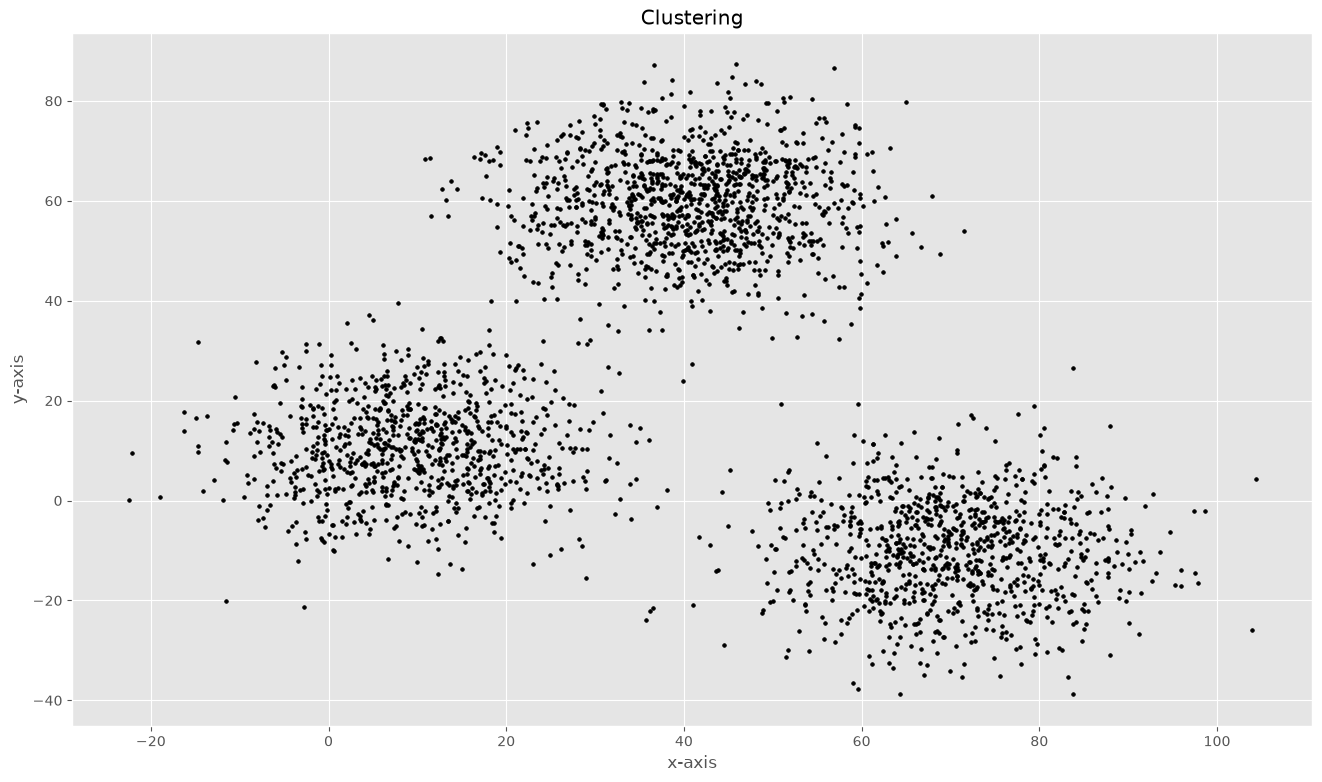

In [23]:
f1=data['V1'].values
f2=data['V2'].values
X=np.array(list(zip(f1,f2)))
plt.figure(figsize=(16,9))
plt.title('Clustering')
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.scatter(f1,f2,c='k',s=7)


In [31]:
len(X)

3000

In [32]:
# Euclidean Distance
def dist(a,b,ax=1):
    return np.linalg.norm(a-b,axis=ax)

In [33]:
k=3
C_x=np.random.randint(0,np.max(X)-20,size=k)
C_y=np.random.randint(0,np.max(X)-20,size=k)
C=np.array(list(zip(C_x,C_y)),dtype=np.float32)
print(C)

[[63. 71.]
 [82. 62.]
 [56. 73.]]


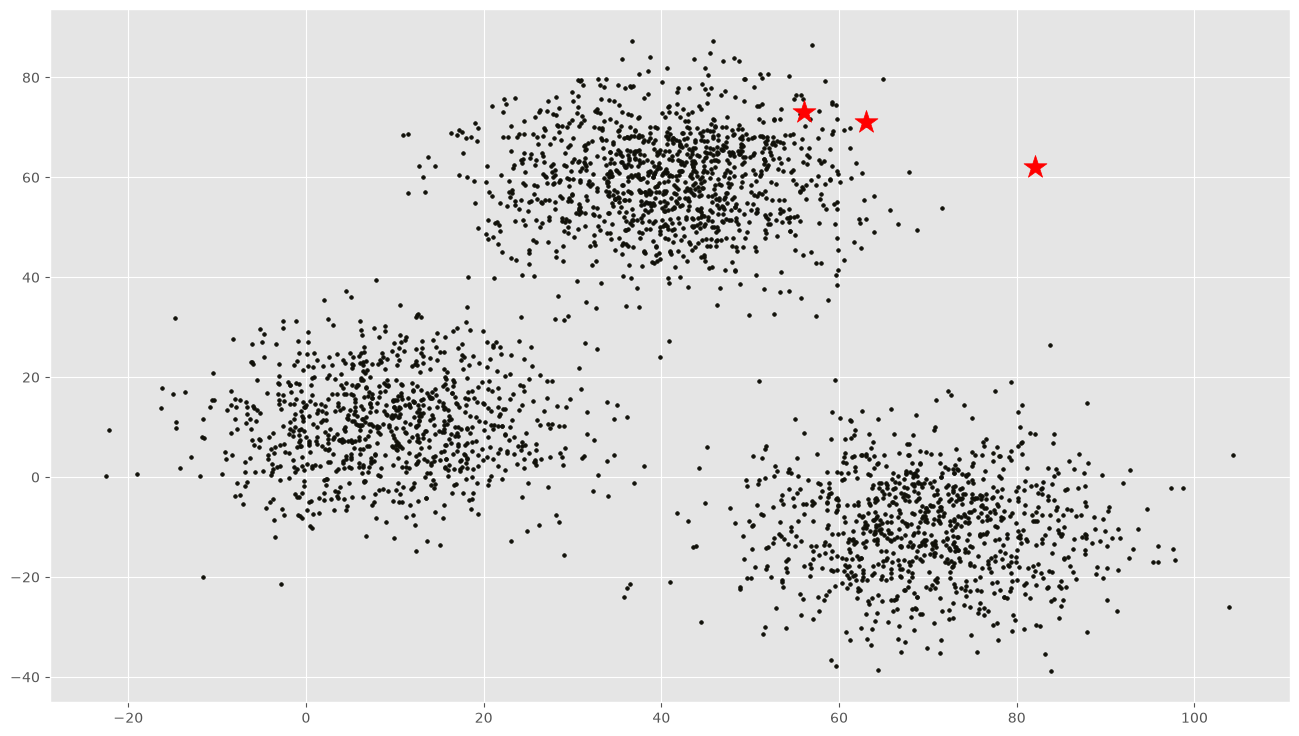

In [49]:
plt.figure(figsize=(16,9))
plt.scatter(f1,f2,c="#11110A",s=7)
plt.scatter(C_x,C_y,marker='*',s=300,c='r')



In [34]:
C_old=np.zeros(C.shape)

In [35]:
C_old

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [36]:
clusters=np.zeros(len(X))

In [37]:
clusters

array([0., 0., 0., ..., 0., 0., 0.], shape=(3000,))

In [52]:
def plotData(points,clusters,C):
    color=['r','g','b','y','c','m']
    fig , ax=plt.Subplot()
    plt.figure(figsize=(16,9))
    for i in range (k):
            points = np.array([X[j] for j in range(len(X))if clusters[j]==i])
            ax.scatter(points[:,0],points[:,1],s=7,c=color[i])
    ax.scatter(C[:,0],C[:,1],marker='*',s=200,c='#050505') 
    plt.show()   



In [50]:
error=dist(C,C_old,None)
while error!=0:
    for i in range(len(X)):
        distances=dist(X[i],C)
        # print("Distance is",distances)
        clusters=np.argmin(distances)
        print("Cluster is",clusters)
        clusters[i]=clusters
    C_old=deepcopy(C)
    for i in range (k):
        points = [X[j]for j in range (len(X))if clusters [j]==i]
        C[i]=np.mean(points,axis=0)
        plotData(points,clusters,C)
    error= dist(C,C_old,None)    

In [48]:
C


array([[63., 71.],
       [82., 62.],
       [56., 73.]], dtype=float32)